# Nichenet analysis from ALTRA Tmem C3 to Bmem C9

specific aims: how does Tmem C3 ligand affect the B effector C9?
- ligand from C3
- receptor on C9
- DEG from C9 vs C8


# Setup

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('nichenetr')

Warning message:
“Your system is mis-configured: ‘/var/db/timezone/localtime’ is not a symlink”
Warning message:
“‘/var/db/timezone/localtime’ is not identical to any known timezone file”
Warning message:
“Failed to locate timezone database”


In [2]:
packageVersion('nichenetr')

[1] ‘2.2.0’

In [3]:
# Check number of cores
future::availableCores()
# Set up parallel processing to run when using 'future' functions 
future::plan(strategy = "multicore", workers = future::availableCores()-3)  
options(future.globals.maxSize = 1000 * 1024^5)
# to turn off parallel processing run line below
# future::plan(strategy = "sequential")

system 
    32

In [4]:
# define file path
data_path <- '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction'
fig_path <- '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures'
output_path <- '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet'
ref_path <- '/home/workspace/private/reference_data/nichenet'
if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- 'ALTRA_nichenet_TmemC3_to_Beff_'

In [5]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [6]:
# load nichenet ligand-receptor database
lr_network <- readRDS(file.path(ref_path, "lr_network_human_21122021.rds"))
ligand_target_matrix <- readRDS(file.path(ref_path, "ligand_target_matrix_nsga2r_final.rds"))
weighted_networks <- readRDS(file.path(ref_path, "weighted_networks_nsga2r_final.rds")) 

# Signal send from Tmem C3 to B effector

## load gene expressed by T mem C3 and get lignads list

In [7]:
# load gene list expressed by Tmem C3
TmemC3_genes <-
    read_csv(file.path(data_path, 'ALTRA_TmemC3_expressed_genes.csv'),
            show_col_types = FALSE)
TmemC3_genes %>% head()

New names:
• `` -> `...1`


...1,genes,props,cell_type
<dbl>,<chr>,<dbl>,<chr>
32030,A1BG,0.1491139,CD4mem_C3
16365,AAED1,0.1186709,CD4mem_C3
3829,AAK1,0.7283544,CD4mem_C3
5117,AAMP,0.1450000,CD4mem_C3
7595,AASDH,0.1162658,CD4mem_C3
18506,AASDHPPT,0.2198101,CD4mem_C3


In [8]:
# load gene list expressed by Beff C9
BeffC9_genes <-
    read_csv(file.path(data_path, 'ALTRA_BeffC9_expressed_genes.csv'),
            show_col_types = FALSE)
BeffC8_genes <-
    read_csv(file.path(data_path, 'ALTRA_BeffC8_expressed_genes.csv'),
            show_col_types = FALSE)
BeffC9_genes %>% head()

New names:
• `` -> `...1`
New names:
• `` -> `...1`


...1,genes,props,cell_type
<dbl>,<chr>,<dbl>,<chr>
32030,A1BG,0.1599073,CD27- effector B cell_C9
16365,AAED1,0.1123986,CD27- effector B cell_C9
5117,AAMP,0.1517961,CD27- effector B cell_C9
18506,AASDHPPT,0.1958285,CD27- effector B cell_C9
27428,AATF,0.3059096,CD27- effector B cell_C9
8189,ABCE1,0.1865585,CD27- effector B cell_C9


In [9]:
# align the gene symbols
# define the sender and receiver genes
expressed_genes_sender = TmemC3_genes$genes
expressed_genes_receiver = union(BeffC9_genes$genes, BeffC8_genes$genes)
# If this is not done, there will be 35 genes fewer in lr_network_expressed!
expressed_genes_sender <- convert_alias_to_symbols(expressed_genes_sender,
                                                   "human", verbose = TRUE)
expressed_genes_receiver <- convert_alias_to_symbols(expressed_genes_receiver,
                                                   "human", verbose = TRUE)

[1] "there are provided symbols that are not in the alias annotation table: "
 [1] "AC004687.1" "AC005332.5" "AC006369.1" "AC007952.4" "AC008105.3"
 [6] "AC008555.5" "AC010642.2" "AC013264.1" "AC013394.1" "AC016831.5"
[11] "AC016831.7" "AC025164.1" "AC026979.2" "AC058791.1" "AC073111.5"
[16] "AC087190.1" "AC087239.1" "AC092683.1" "AC093323.1" "AC097376.2"
[21] "AC103591.3" "AC114760.2" "AC118549.1" "AC243960.1" "AC245014.3"
[26] "AC245297.3" "AL133342.1" "AL133453.1" "AL365361.1" "AL445686.2"
[31] "AL662844.4" "AP002387.2" "GARS"       "MATR3-1"    "POLR2J3-1" 
[36] "QARS"       "SARS"       "SEPT2"      "TAZ"       
[1] "they are added to the alias annotation table, so they don't get lost"
[1] "following are the official gene symbols of input aliases: "
       symbol      alias
1       ADSS2       ADSS
2      ANTKMT    FAM173A
3      ATP5MJ    ATP5MPL
4      ATP5MK     ATP5MD
5        BBLN    C9orf16
6       CARS1       CARS
7     CENATAC     CCDC84
8       CEP20      FOPNL
9       CE

In [10]:
# filter the expressed ligands and receptors to only those that putatively bind together
ligands <- lr_network %>% pull(from) %>% unique()
expressed_ligands <- intersect(ligands,expressed_genes_sender)

receptors <- lr_network %>% pull(to) %>% unique()
expressed_receptors <- intersect(receptors,expressed_genes_receiver)

potential_ligands <-  lr_network %>% filter(from %in% expressed_ligands & to %in% expressed_receptors) %>% 
  pull(from) %>% unique()

head(potential_ligands)

[1] "ADAM10"  "ADAM17"  "ADGRE5"  "ALOX5AP" "APP"     "B2M"

In [11]:
ligands[ligands=='REN64']

character(0)

In [12]:
potential_ligands

[1] "ADAM10"   "ADAM17"   "ADGRE5"   "ALOX5AP"  "APP"      "B2M"     
 [7] "BST2"     "CALR"     "CD2"      "CD28"     "CD320"    "CD40LG"  
[13] "CD52"     "CD55"     "CD6"      "CD7"      "CD82"     "CD99"    
[19] "COPA"     "CTSD"     "GNAS"     "GPI"      "HLA-A"    "HLA-B"   
[25] "HLA-C"    "HLA-DRA"  "HLA-DRB1" "HLA-F"    "HMGB1"    "ICAM2"   
[31] "ICAM3"    "IFITM1"   "ITGB2"    "LFNG"     "LGALS1"   "LGALS3"  
[37] "LGALS9"   "LTB"      "LYZ"      "MFNG"     "MIF"      "NAMPT"   
[43] "PSEN1"    "PTDSS1"   "PTPRC"    "S100A8"   "S100A9"   "SELPLG"  
[49] "SEMA4D"   "SIRPG"    "ST6GAL1"  "TGFB1"    "TGOLN2"   "TIMP1"   
[55] "TNFRSF14" "TSPAN3"   "TSPAN5"   "ZDHHC5"

In [13]:
potential_ligands%>%length()
expressed_receptors%>%length()

[1] 58

[1] 138

In [14]:
potential_ligands

[1] "ADAM10"   "ADAM17"   "ADGRE5"   "ALOX5AP"  "APP"      "B2M"     
 [7] "BST2"     "CALR"     "CD2"      "CD28"     "CD320"    "CD40LG"  
[13] "CD52"     "CD55"     "CD6"      "CD7"      "CD82"     "CD99"    
[19] "COPA"     "CTSD"     "GNAS"     "GPI"      "HLA-A"    "HLA-B"   
[25] "HLA-C"    "HLA-DRA"  "HLA-DRB1" "HLA-F"    "HMGB1"    "ICAM2"   
[31] "ICAM3"    "IFITM1"   "ITGB2"    "LFNG"     "LGALS1"   "LGALS3"  
[37] "LGALS9"   "LTB"      "LYZ"      "MFNG"     "MIF"      "NAMPT"   
[43] "PSEN1"    "PTDSS1"   "PTPRC"    "S100A8"   "S100A9"   "SELPLG"  
[49] "SEMA4D"   "SIRPG"    "ST6GAL1"  "TGFB1"    "TGOLN2"   "TIMP1"   
[55] "TNFRSF14" "TSPAN3"   "TSPAN5"   "ZDHHC5"

In [15]:
# Define the gene set of interest and a background of genes
# This should be gene differentiated C8 and C9
c9_degs <- read_csv(file.path(output_path, 'ALTRA_scRNA_Bmem_certPro_leiden_0_8c9vsc8_wilcoxon_sig_degs.csv'), 
                    show_col_types = FALSE)
geneset_oi = c9_degs %>% filter(pvals_adj<0.01& abs(logfoldchanges)>1) %>% pull(names)
geneset_oi <- convert_alias_to_symbols(geneset_oi,  "human", verbose = TRUE)
geneset_oi %>% length()


New names:
• `` -> `...1`


[1] "there are provided symbols that are not in the alias annotation table: "
[1] "AC090152.1" "AL139020.1" "AC108863.1"
[1] "they are added to the alias annotation table, so they don't get lost"
[1] "following are the official gene symbols of input aliases: "
     symbol    alias
1     H1-10     H1FX
2 LINC02908 C9orf139
3   MARCHF3   MARCH3
4    NIBAN1  FAM129A
5    NIBAN3  FAM129C
6    PLAAT4  RARRES3
7     RESF1 KIAA1551
8  SEPTIN11   SEPT11
9     WARS1     WARS


[1] 284

In [16]:
background_expressed_genes <- expressed_genes_receiver %>% .[. %in% rownames(ligand_target_matrix)]
background_expressed_genes = background_expressed_genes[!background_expressed_genes%in% geneset_oi]
length(background_expressed_genes)

[1] 4801

## Perform NicheNet ligand activity analysis

In [17]:
ligand_activities <- predict_ligand_activities(geneset = geneset_oi,
                                               background_expressed_genes = background_expressed_genes,
                                               ligand_target_matrix = ligand_target_matrix,
                                               potential_ligands = potential_ligands)

In [18]:
ligand_activities <- ligand_activities %>% arrange(-aupr_corrected) %>%
  mutate(rank = rank(desc(aupr_corrected)))
ligand_activities

test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TGFB1,0.6303384,0.11508779,0.05979460,0.146440945,1
SEMA4D,0.5525506,0.09997165,0.04467846,0.084061609,2
ADAM17,0.5902748,0.09832151,0.04302832,0.084488723,3
HLA-C,0.5895120,0.09649922,0.04120603,0.080459085,4
CD40LG,0.5976657,0.09625693,0.04096374,0.073524682,5
CD7,0.5709453,0.09602756,0.04073437,0.065914762,6
PTPRC,0.5634565,0.09563797,0.04034478,0.089058936,7
LFNG,0.5830810,0.09375129,0.03845810,0.074855173,8
S100A8,0.5641533,0.09357211,0.03827892,0.081436480,9


In [29]:
ligand_activities %>% write_csv(file.path(output_path, paste0(proj_name, 
                                                             'TmemC3_BeffectorC9vsC8.csv')))

In [20]:
best_upstream_ligands <- ligand_activities %>% top_n(20, aupr_corrected) %>%
  arrange(-aupr_corrected) %>% pull(test_ligand)

In [21]:
best_upstream_ligands

[1] "TGFB1"   "SEMA4D"  "ADAM17"  "HLA-C"   "CD40LG"  "CD7"     "PTPRC"  
 [8] "LFNG"    "S100A8"  "MFNG"    "ADAM10"  "PSEN1"   "ZDHHC5"  "CD2"    
[15] "CD82"    "NAMPT"   "CD28"    "ALOX5AP" "CD52"    "LGALS9"

In [27]:
ligand_oi = c( 'CD40LG', 'LGALS1','CD28',
                          'LGALS9','SEMA4D','CD52','ADAM10',
                          'SIRPG','ST6GAL1', 'PTDSS1')
best_upstream_ligands = ligand_activities%>% filter(test_ligand%in%ligand_oi)%>%
  arrange(desc(aupr_corrected))%>% pull(test_ligand)
best_upstream_ligands

[1] "SEMA4D"  "CD40LG"  "ADAM10"  "CD28"    "CD52"    "LGALS9"  "SIRPG"  
 [8] "LGALS1"  "ST6GAL1" "PTDSS1"

In [28]:
ligand_activities%>% filter(test_ligand%in%ligand_oi)%>%
  arrange(-aupr_corrected)

test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SEMA4D,0.5525506,0.09997165,0.04467846,0.084061609,2
CD40LG,0.5976657,0.09625693,0.04096374,0.073524682,5
ADAM10,0.5735404,0.09142839,0.03613520,0.064986935,11
CD28,0.5698105,0.09009924,0.03480605,0.049155119,17
CD52,0.5767322,0.08857771,0.03328452,0.053972313,19
LGALS9,0.5674177,0.08837163,0.03307844,0.061722781,20
SIRPG,0.5528085,0.08482667,0.02953348,0.059613003,36
LGALS1,0.5587696,0.08439639,0.02910320,0.032932296,40
ST6GAL1,0.5558002,0.07337758,0.01808439,-0.002965152,52


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


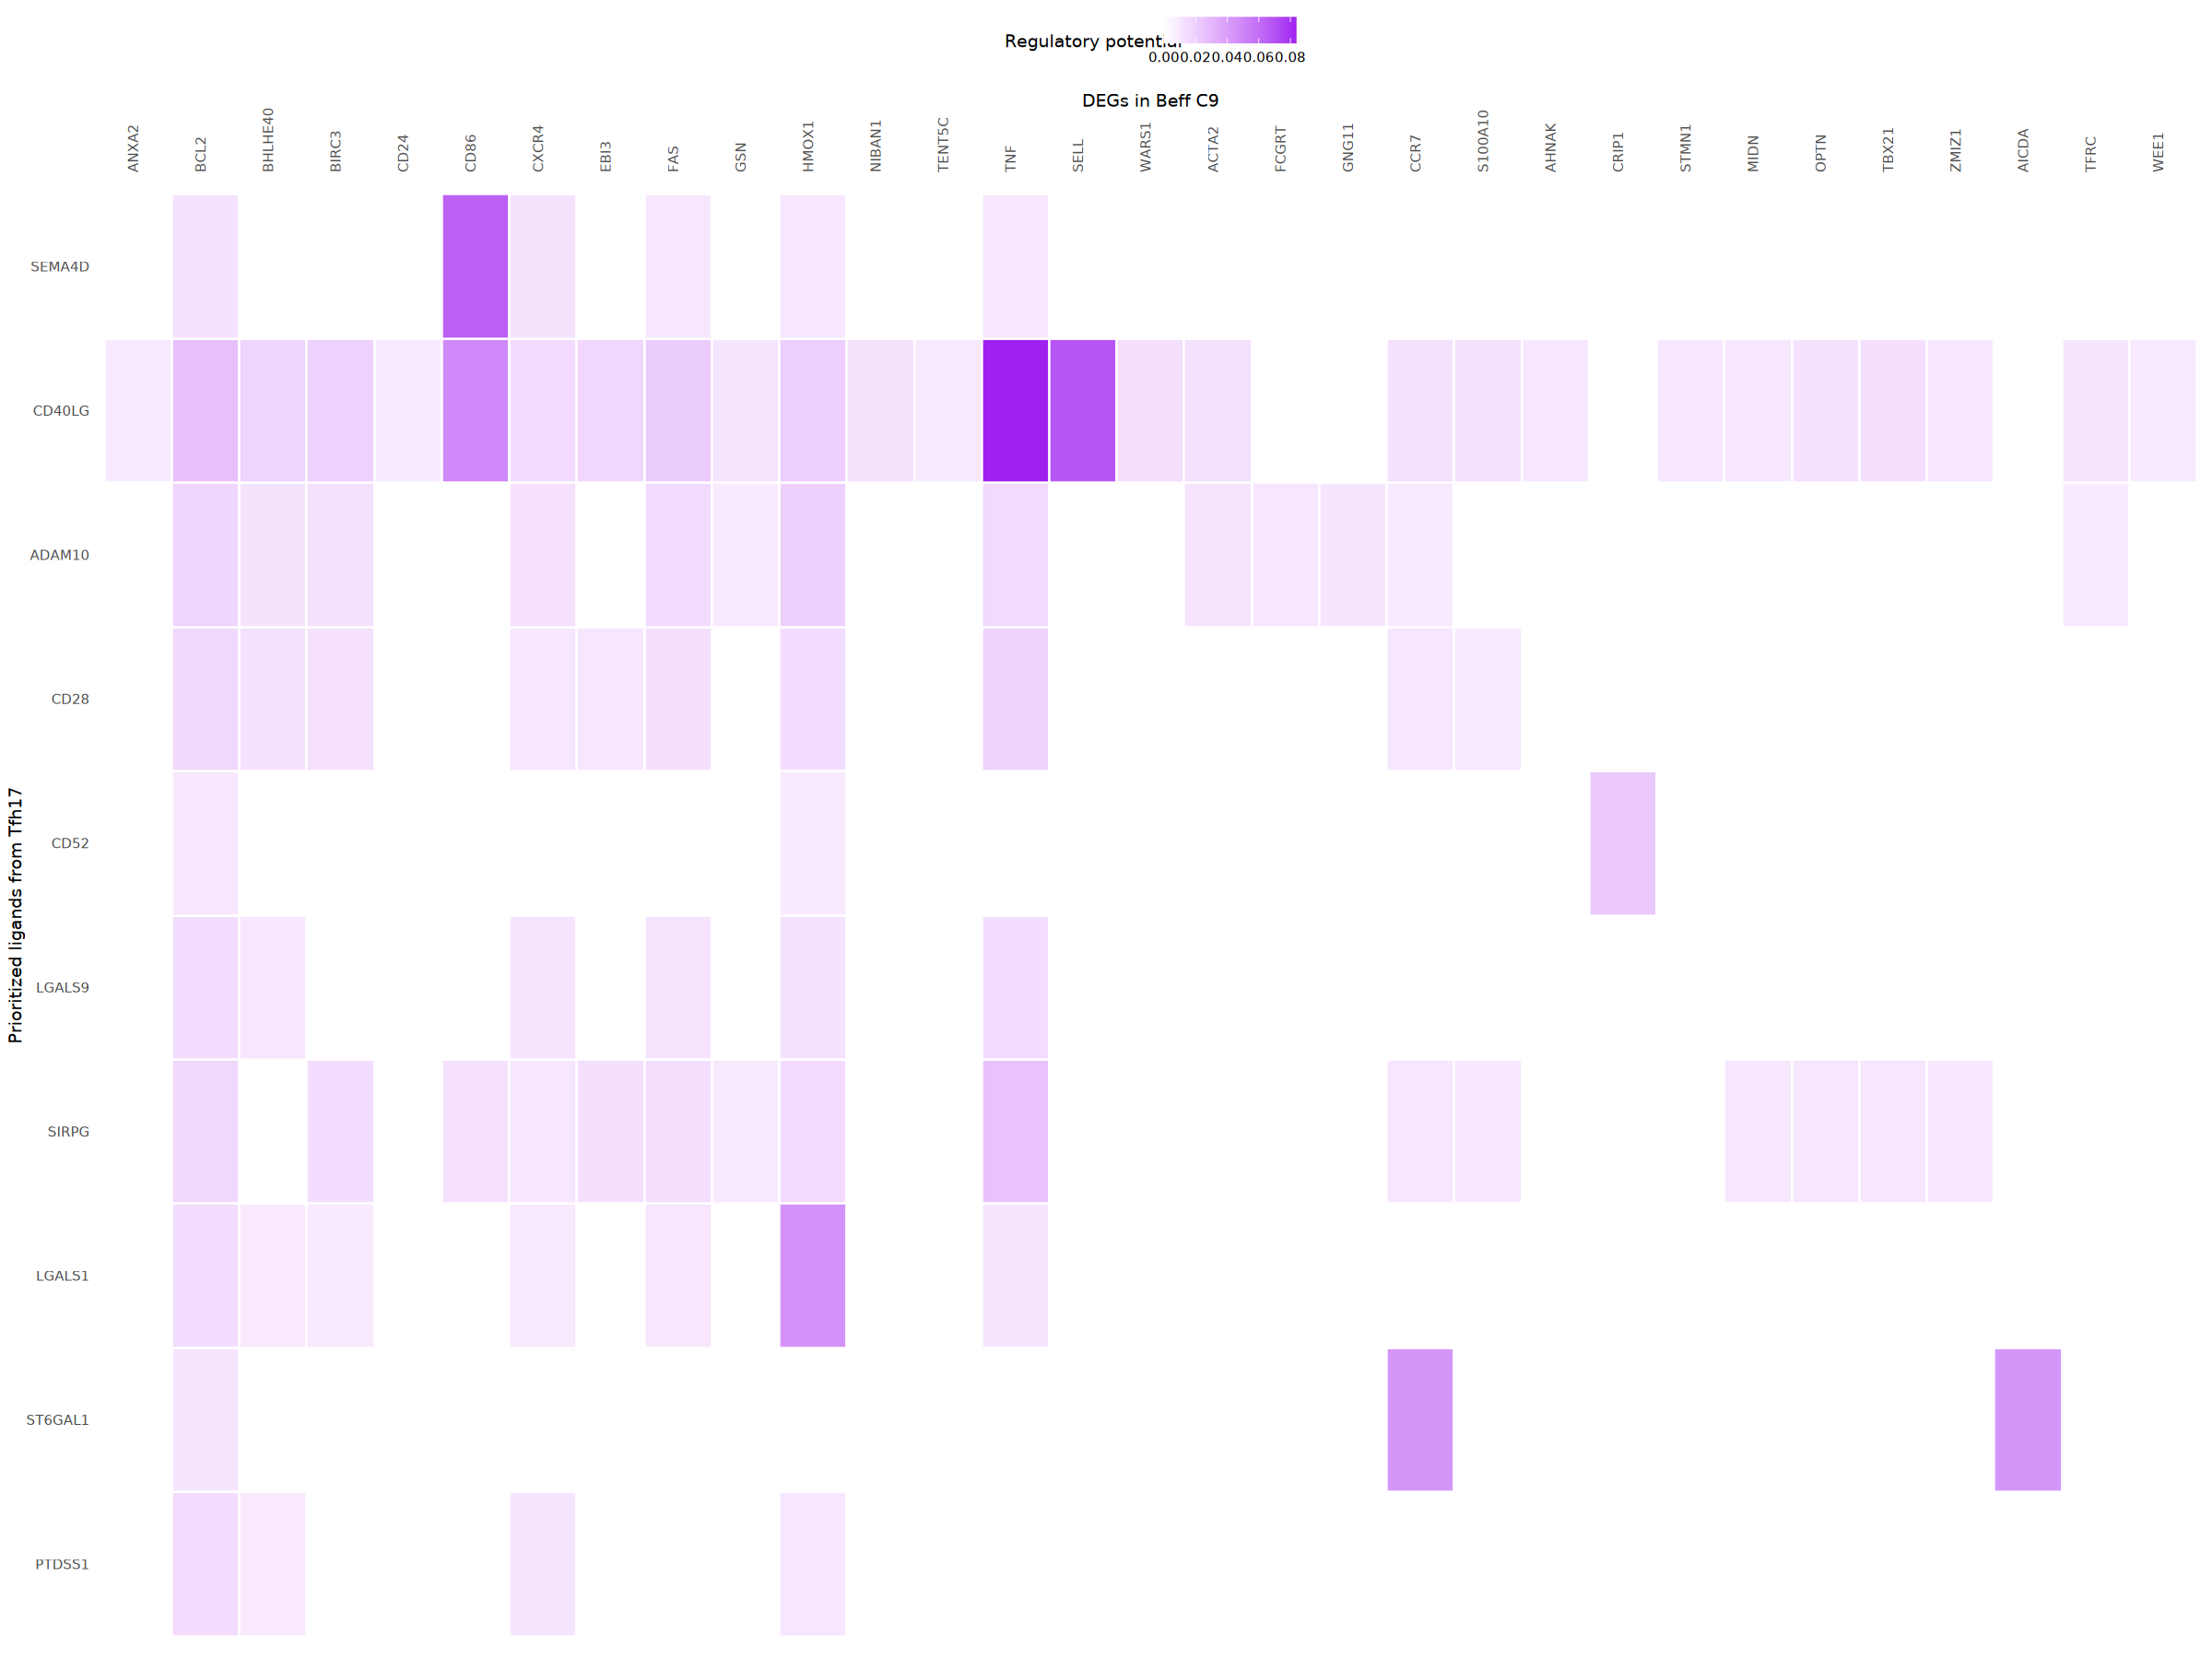

In [24]:
active_ligand_target_links_df <- best_upstream_ligands %>%
  lapply(get_weighted_ligand_target_links,
         geneset = geneset_oi,
         ligand_target_matrix = ligand_target_matrix,
         n = 200) %>% bind_rows()

active_ligand_target_links <- prepare_ligand_target_visualization(
  ligand_target_df = active_ligand_target_links_df,
  ligand_target_matrix = ligand_target_matrix,
  cutoff = 0.25)

order_ligands <- intersect(best_upstream_ligands, colnames(active_ligand_target_links)) %>% rev()
order_targets <- active_ligand_target_links_df$target %>% unique() %>% intersect(rownames(active_ligand_target_links))

vis_ligand_target <- t(active_ligand_target_links[order_targets,order_ligands])

p_ligand_target_network <- 
    make_heatmap_ggplot(vis_ligand_target, "Prioritized ligands from Tfh17", 
                                               "DEGs in Beff C9",
                    color = "purple", legend_title = "Regulatory potential") +
    scale_fill_gradient2(low = "whitesmoke",  high = "purple")

p_ligand_target_network
ggsave(file.path(fig_path, paste0(proj_name, 'TmemC3_BeffC9_C8_ligand_target_genes.pdf')), width = 8, height = 6)

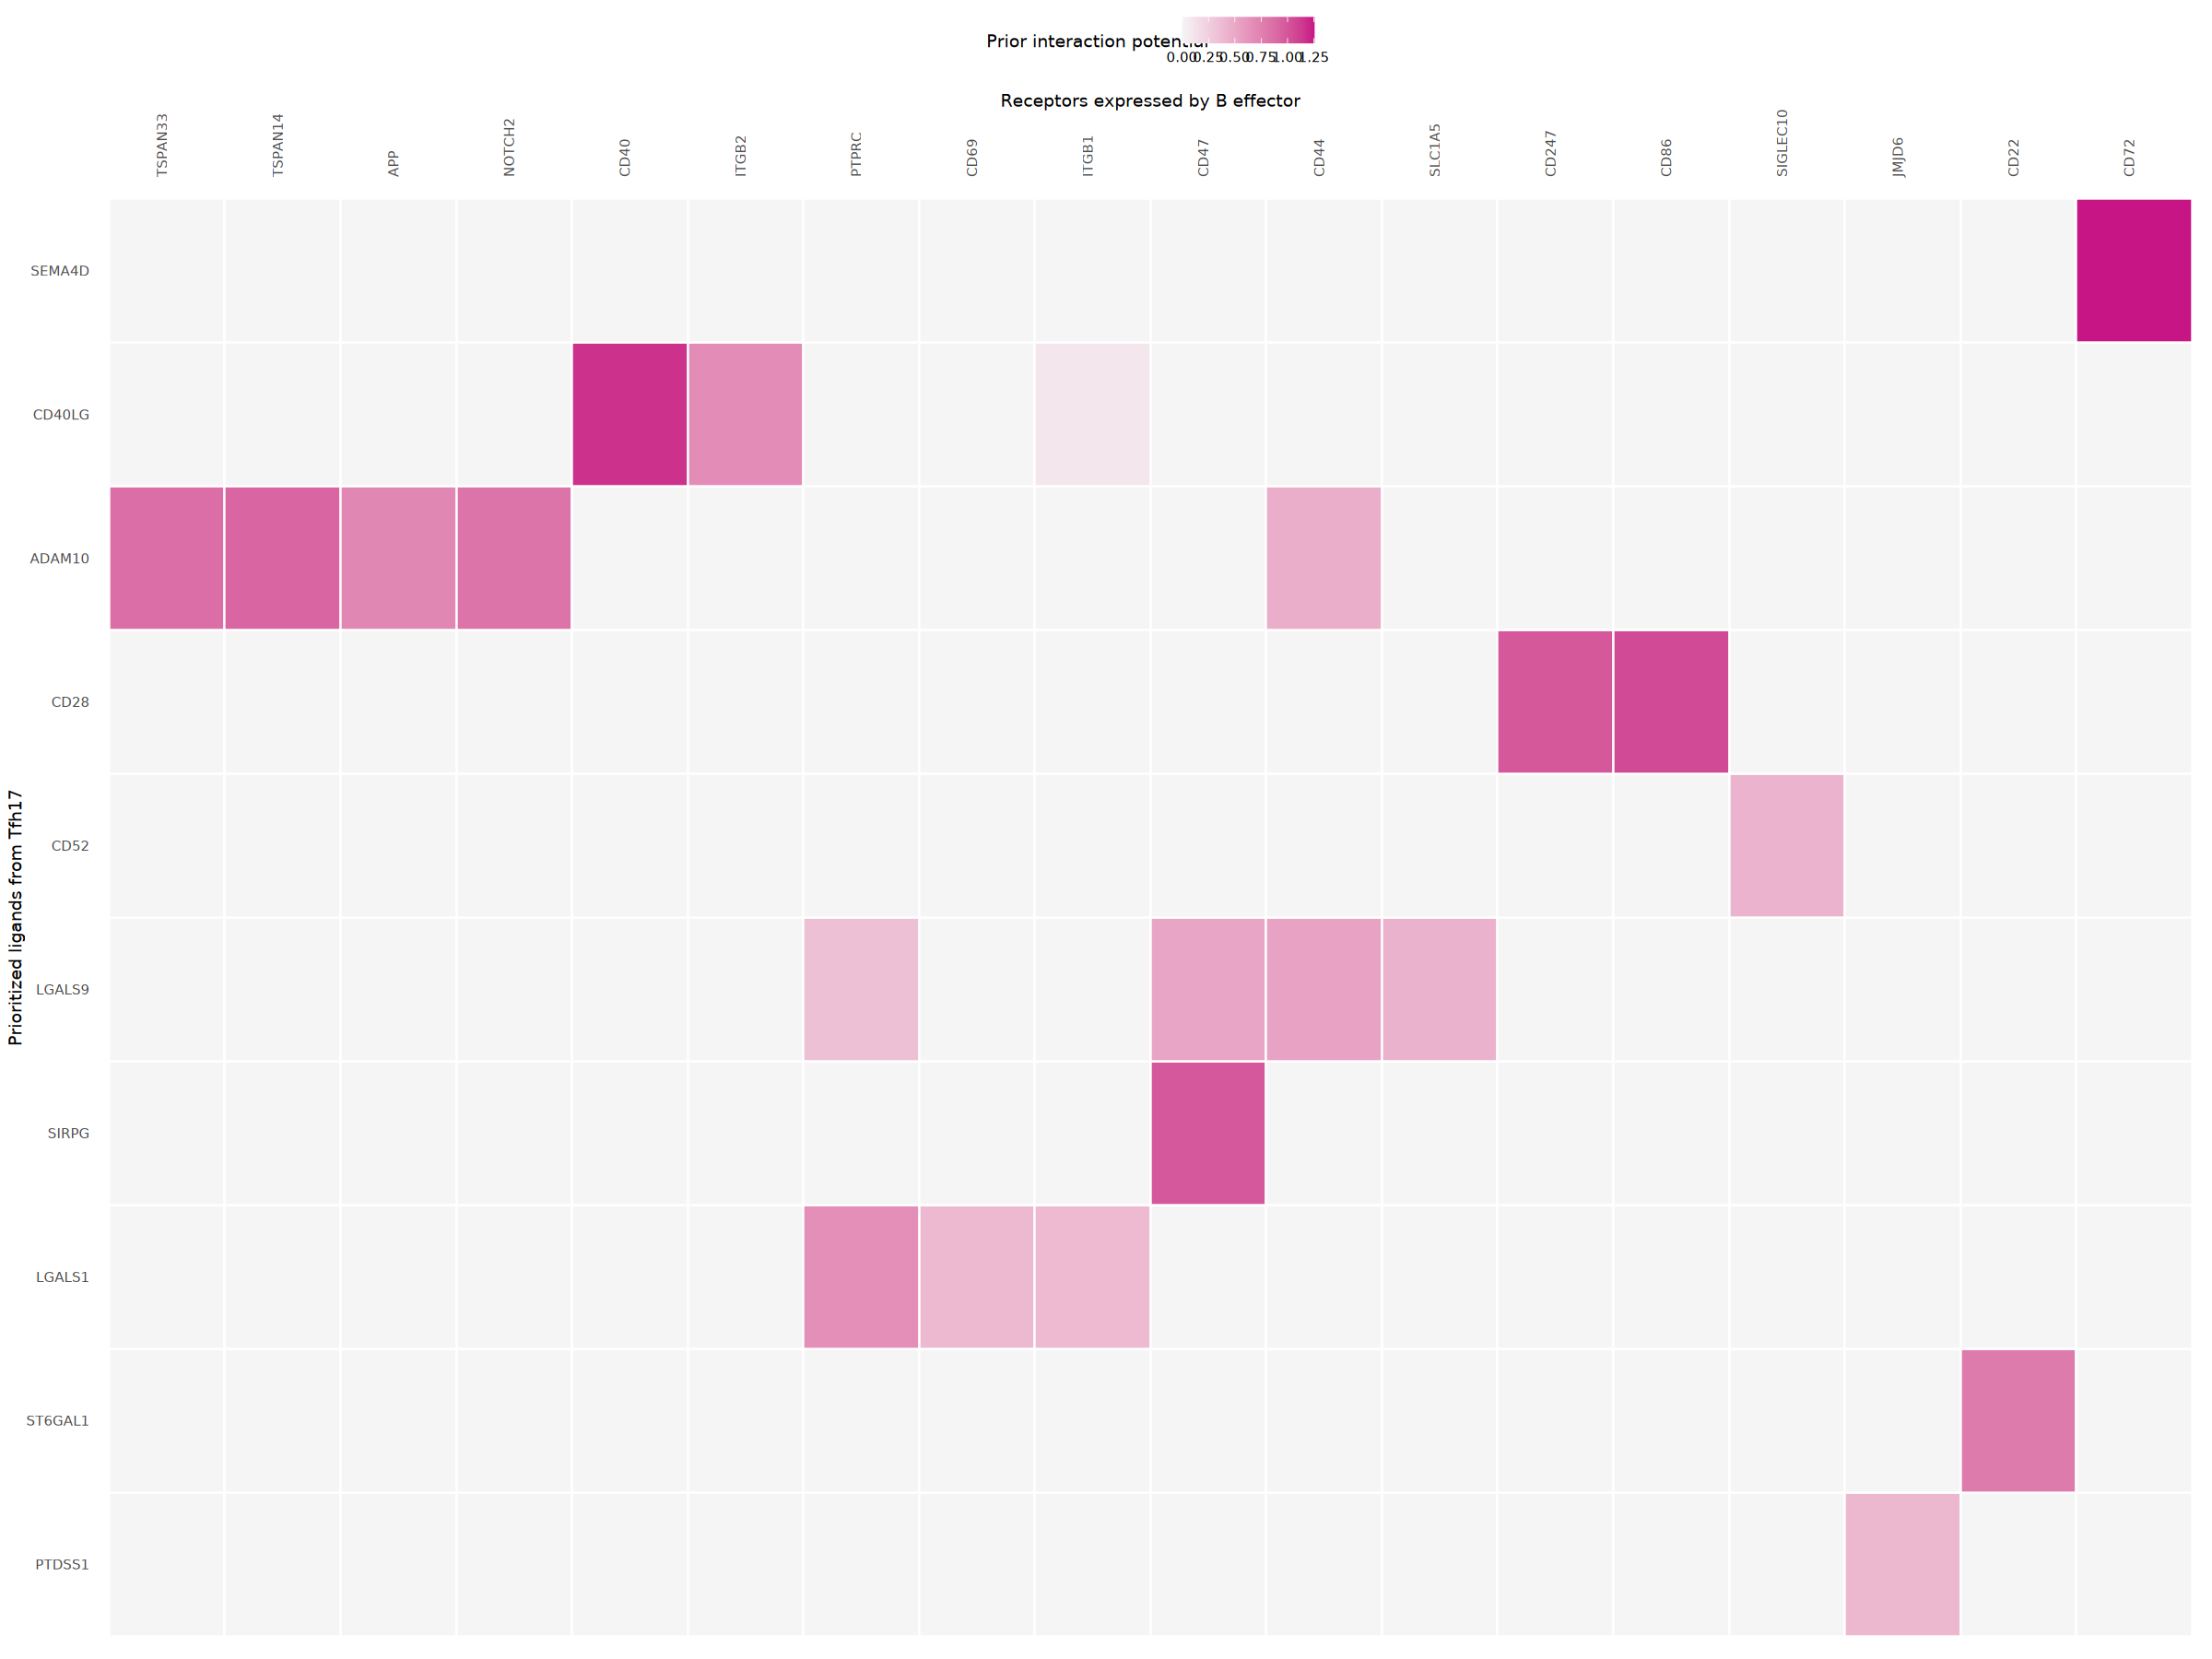

In [25]:
# plot the ligand receptor relationship
ligand_receptor_links_df <- get_weighted_ligand_receptor_links(
  best_upstream_ligands, expressed_receptors,
  lr_network, weighted_networks$lr_sig) 

vis_ligand_receptor_network <- prepare_ligand_receptor_visualization(
  ligand_receptor_links_df,
  best_upstream_ligands,
  order_hclust = "receptors") 

(make_heatmap_ggplot(t(vis_ligand_receptor_network), 
                     y_name = "Prioritized ligands from Tfh17", x_name = "Receptors expressed by B effector",  
                     color = "mediumvioletred", legend_title = "Prior interaction potential"))
ggsave(file.path(fig_path, paste0(proj_name, 'TmemC3_BeffC9_C8_ligand_receptor_genes.png')), width = 8, height = 6)